<a href="https://colab.research.google.com/github/tanuiivy/bbt4106-202604-D4-clustering/blob/feature%2Fpreprocessing-Angela/lab_submission/bbt4106_202604_D4_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Intelligence II | Group D4 Notebook for Lab On Clustering

##0. Setup and Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import os

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

##1. Data loading and EDA

## 1.1 Load the dataset and check shape

In [ ]:
# Load the dataset
dataset_path = './data/agricultural_cooperative_farmers.csv'
url = 'https://raw.githubusercontent.com/tanuiivy/bbt4106-202604-D4-clustering/main/data/agricultural_cooperative_farmers.csv'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    if not os.path.exists('./data'):
        os.makedirs('./data')
    urllib.request.urlretrieve(url, dataset_path)
    print("Dataset downloaded")
else:
    print("Dataset already exists")

df = pd.read_csv(dataset_path)

# Check rows and columns of the dataset
n_rows, n_cols = df.shape
print(f"The dataset has {n_rows} rows and {n_cols} columns.")

print("Shape:", df.shape)
df.head()

Dataset downloaded
The dataset has 680 rows and 7 columns.
Shape: (680, 7)


,farmer_id,crop_type,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
0,1,Horticulture,16.29,35.9,2000.0,7.0,51.718276
1,2,Maize,8.19,4.0,81018.0,3.9,60.453885
2,3,Dairy,5.64,4.9,39787.0,4.7,17.004114
3,4,Maize,56.21,206.7,96659.0,17.4,39.364960
4,5,Maize,4.66,6.9,150561.0,9.3,52.062909


## 1.2 Confirm data types and check missing values

In [ ]:
# Confirm data types for each column
print("Data types:\n", df.dtypes)

# Count missing values in each column
print("\nMissing values per column:\n", df.isna().sum())

Data types:
 farmer_id                     int64
crop_type                    object
farm_size_acres             float64
annual_yield_tonnes         float64
income_per_acre_kes         float64
years_farming_experience    float64
market_access_score         float64
dtype: object

Missing values per column:
 farmer_id                    0
crop_type                    0
farm_size_acres              0
annual_yield_tonnes          0
income_per_acre_kes          0
years_farming_experience     0
market_access_score         30
dtype: int64


## 1.3 Compute frequency, central tendency and distribution measures for each numeric feature

In [ ]:
numeric_cols = ["farm_size_acres", "annual_yield_tonnes", "income_per_acre_kes",
                 "years_farming_experience", "market_access_score"]

df[numeric_cols].describe()

,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience,market_access_score
count,680.000000,680.000000,680.000000,680.000000,650.000000
mean,10.164794,30.708529,51914.347059,10.250441,52.864576
std,14.578449,55.530478,40581.498684,6.040511,22.957492
min,0.200000,0.100000,2000.000000,0.500000,0.000000
25%,1.507500,4.000000,21174.250000,5.700000,38.411711
50%,3.640000,9.800000,39243.500000,9.050000,53.319143
75%,11.102500,20.200000,73660.500000,14.100000,68.988054
max,73.820000,272.700000,230508.000000,33.100000,100.000000


In [ ]:
print("""
farm_size_acres ranges from 0.2 to 73.28 acres with a mean of 10.164794 and a median of 3.64.

annual_yield_tonnes ranges from 0.10 to 272.70 tonnes with a mean of 30.708529 and a median of 9.80.

income_per_acre_kes ranges from 2,000 to 230,508 KES with a mean of 51,914.347059 and a median of 39,243.5.

years_farming_experience ranges from 0.50 to 33.1 years with a mean of 10.250441 and a median of 9.05.

market_access_score ranges from 0 to 100 with a mean of 52.864576 and a median of 53.319143.
""")


farm_size_acres ranges from 0.2 to 73.28 acres with a mean of 10.164794 and a median of 3.64.

annual_yield_tonnes ranges from 0.10 to 272.70 tonnes with a mean of 30.708529 and a median of 9.80.

income_per_acre_kes ranges from 2,000 to 230,508 KES with a mean of 51,914.347059 and a median of 39,243.5.

years_farming_experience ranges from 0.50 to 33.1 years with a mean of 10.250441 and a median of 9.05.

market_access_score ranges from 0 to 100 with a mean of 52.864576 and a median of 53.319143.



## 1.4 Categorical feature frequency

In [ ]:
df["crop_type"].value_counts()

,count
crop_type,
Maize,216
Horticulture,135
Coffee,119
Tea,109
Dairy,101


In [ ]:
print("""
crop_type is a categorical feature, which helps us count how many farmers grow each crop.
The cooperative has 5 crop types: Maize (216 farmers), Horticulture (135 farmers), Coffee (119 farmers), Tea (109 farmers), and Dairy (101 farmers).
Maize is the most grown crop while the other four crops are close in terms of number of farmers growing them.
""")


crop_type is a categorical feature, which helps us count how many farmers grow each crop.
The cooperative has 5 crop types: Maize (216 farmers), Horticulture (135 farmers), Coffee (119 farmers), Tea (109 farmers), and Dairy (101 farmers).
Maize is the most grown crop while the other four crops are close in terms of number of farmers growing them.



## 1.5 Visualizations

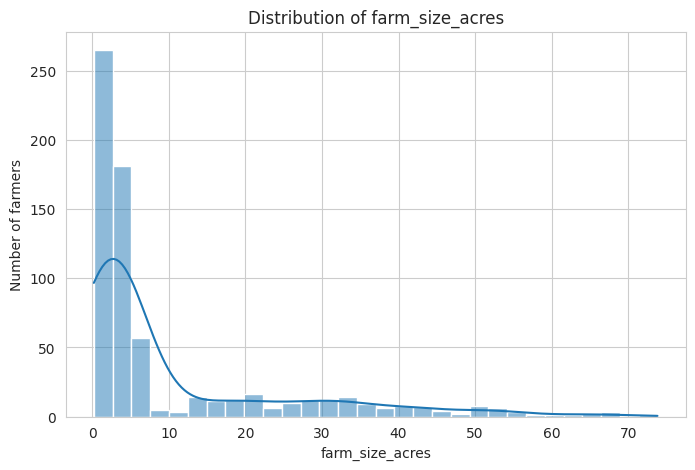

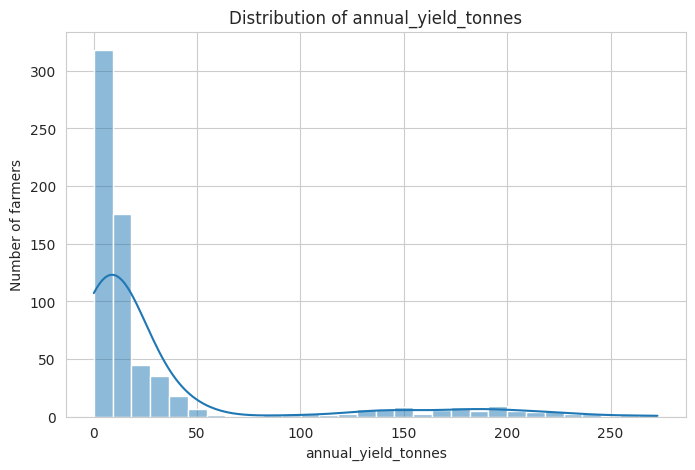

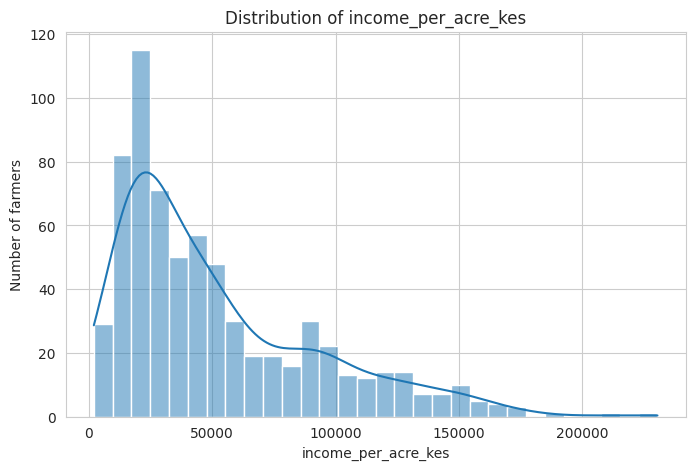

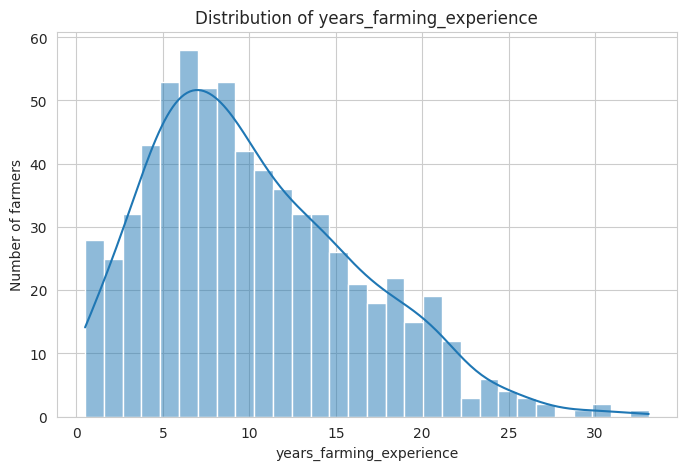

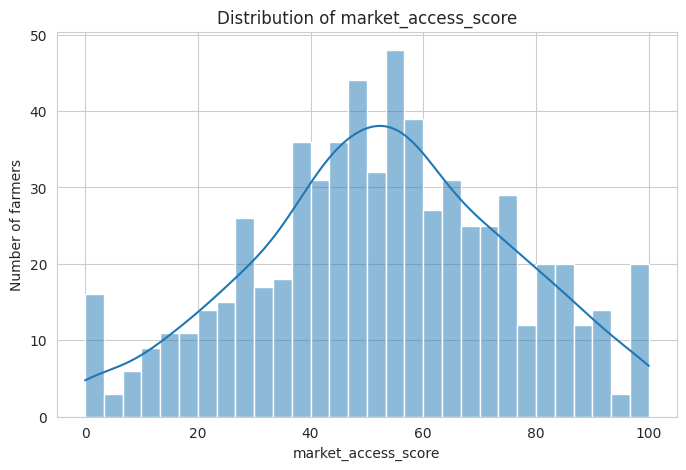

In [ ]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of farmers")
    plt.show()

In [ ]:
print("""
farm_size_acres: Most farmers have small farms which are under 10 acres. A small number of farmers have larger farms of almost 75 acres.

annual_yield_tonnes: Most farmers produce small yields, with only a few producing very large amounts of over 250 tonnes.

income_per_acre_kes: Most farmers earn between about 10,000 and 60,000 KES per acre with a peak income of around 25,000.
A smaller group of farmers earn much more, up to over 200,000 KES per acre.

years_farming_experience: Most farmers have between 5 and 15 years of experience. We have few farmers who are new to farming and very experienced in farming.

market_access_score: This is the most evenly spread feature. Most farmers have a market access score of around 50.
""")


farm_size_acres: Most farmers have small farms which are under 10 acres. A small number of farmers have larger farms of almost 75 acres.

annual_yield_tonnes: Most farmers produce small yields, with only a few producing very large amounts of over 250 tonnes.

income_per_acre_kes: Most farmers earn between about 10,000 and 60,000 KES per acre with a peak income of around 25,000.
A smaller group of farmers earn much more, up to over 200,000 KES per acre.

years_farming_experience: Most farmers have between 5 and 15 years of experience. We have few farmers who are new to farming and very experienced in farming.

market_access_score: This is the most evenly spread feature. Most farmers have a market access score of around 50.



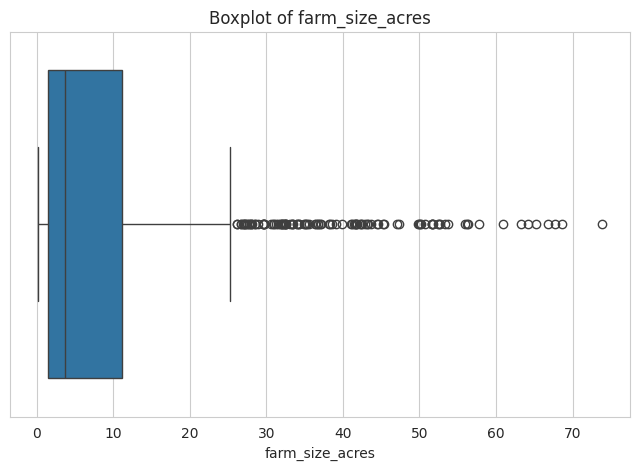

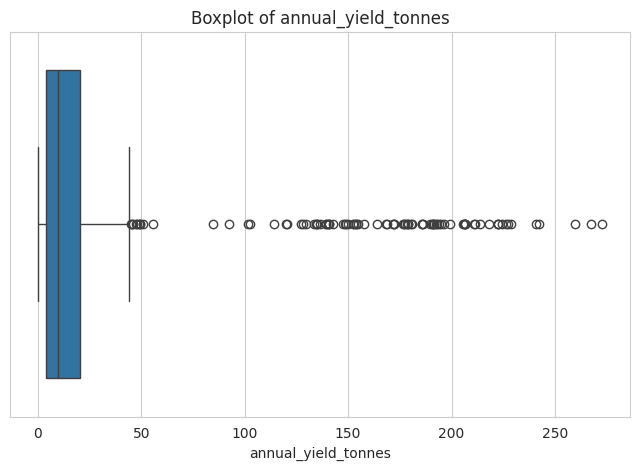

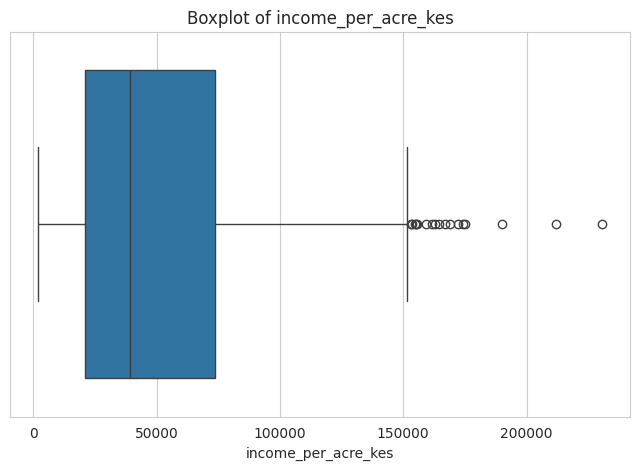

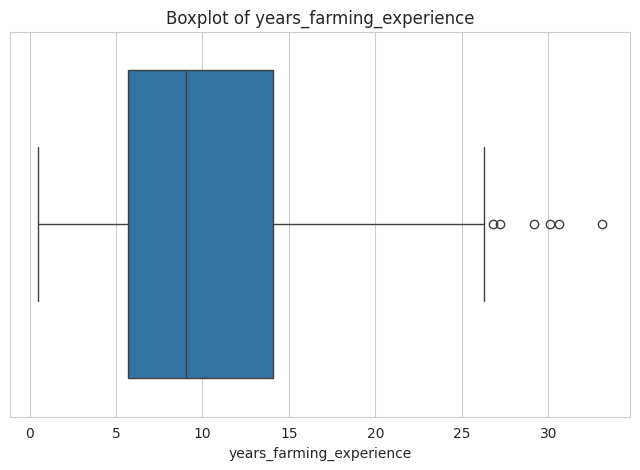

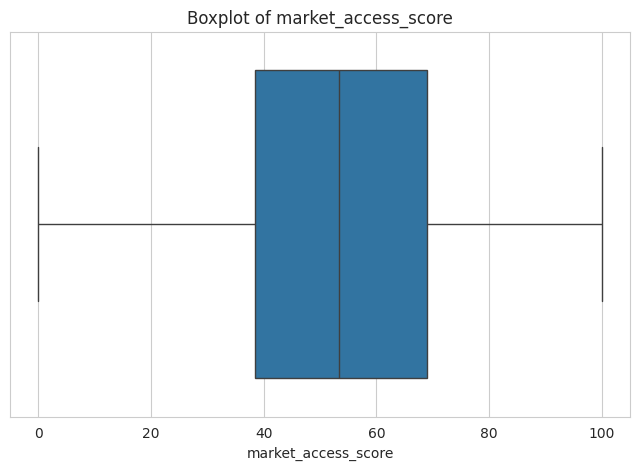

In [ ]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
print("""
farm_size_acres: This has many outliers, starting from around 25 acres to aroud 75 acres.

annual_yield_tonnes: This has many outliers ranging from around 49 tonnes to over 250 tonnes.

income_per_acre_kes: The outliers range above 150,000 KES per acre going up to around 230,000 KES per acre.

years_farming_experience: This has a small number of outliers from around 26 years, up to around 33 years.

market_access_score: This has no outliers at all hence every value falls within the normal range.
""")


farm_size_acres: This has many outliers, starting from around 25 acres to aroud 75 acres.

annual_yield_tonnes: This has many outliers ranging from around 49 tonnes to over 250 tonnes.

income_per_acre_kes: The outliers range above 150,000 KES per acre going up to around 230,000 KES per acre.

years_farming_experience: This has a small number of outliers from around 26 years, up to around 33 years.

market_access_score: This has no outliers at all hence every value falls within the normal range.



In [ ]:
print("""
farm_size_acres, annual_yield_tonnes, and income_per_acre_kes have the most outliers, and these are the same features that were right skewed in the histograms.
This shows that these features need to be scaled before clustering, so that the outliers don't unfairly influence how clusters are formed.
""")


farm_size_acres, annual_yield_tonnes, and income_per_acre_kes have the most outliers, and these are the same features that were right skewed in the histograms.
This shows that these features need to be scaled before clustering, so that the outliers don't unfairly influence how clusters are formed.



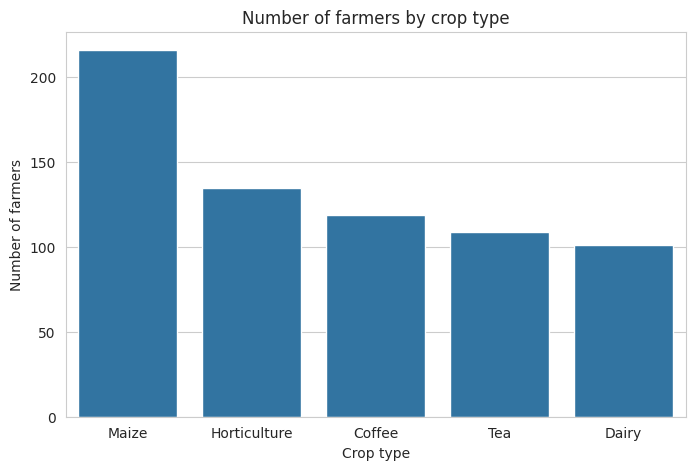

In [ ]:
plt.figure()
sns.countplot(data=df, x="crop_type", order=df["crop_type"].value_counts().index)
plt.title("Number of farmers by crop type")
plt.xlabel("Crop type")
plt.ylabel("Number of farmers")
plt.show()

In [ ]:
print(""""
Maize is the most common crop grown by 216 farmers. Horticulture is grown by 135 farmers, Coffee by 119 farmers, Tea by 109 farmers, and Dairy by 101 farmers.
This shows that the cooperative is not balanced across the five crops because Maize is the most dominant group.
""")

"
Maize is the most common crop grown by 216 farmers. Horticulture is grown by 135 farmers, Coffee by 119 farmers, Tea by 109 farmers, and Dairy by 101 farmers.
This shows that the cooperative is not balanced across the five crops because Maize is the most dominant group.



##2. Feature inclusion and exclusion justification

## 2.1 Features selected for clustering

In [ ]:
clustering_features = ["farm_size_acres", "annual_yield_tonnes", "income_per_acre_kes",
                        "years_farming_experience", "market_access_score"]

print("The features used for clustering are:")
for f in clustering_features:
    print(f)

The features used for clustering are:
farm_size_acres
annual_yield_tonnes
income_per_acre_kes
years_farming_experience
market_access_score


## 2.2 Justification for excluding farmer_id

In [ ]:
print("Unique farmer_id values:", df["farmer_id"].nunique())
print("Total rows:", len(df))

Unique farmer_id values: 680
Total rows: 680


In [ ]:
print("""
farmer_id is excluded from every statistic, plot and in clustering because it is a unique identifier, where each farmer has a unique ID.
It does not describe anything about a farmer's farm, so it is not meaningful to be used in clustering.
""")


farmer_id is excluded from every statistic, plot and in clustering because it is a unique identifier, where each farmer has a unique ID.
It does not describe anything about a farmer's farm, so it is not meaningful to be used in clustering.



## 2.3 Justification for reserving crop_type

In [ ]:
print("crop_type categories:", df["crop_type"].unique())
print("Number of categories:", df["crop_type"].nunique())

crop_type categories: ['Horticulture' 'Maize' 'Dairy' 'Tea' 'Coffee']
Number of categories: 5


In [ ]:
print("""
crop_type is a categorical feature that describes what a farmer grows such as Maize, Tea, Coffee, Dairy, or Horticulture.
Since it is not a number it cannot be used in clustering.
Performing one hot encoding would also be wrong because Maize is the dominant crop type grown by many farmers.
It is reserved for profiling clusters after they are formed.
""")


crop_type is a categorical feature that describes what a farmer grows such as Maize, Tea, Coffee, Dairy, or Horticulture.
Since it is not a number it cannot be used in clustering.
Performing one hot encoding would also be wrong because Maize is the dominant crop type grown by many farmers.
It is reserved for profiling clusters after they are formed.



# Correlation check and preprocessing

Run a correlation matrix or heatmap on the numeric clustering features, before you cluster.

State whether any feature pair risks double-counting the same signal.

Apply scaling, and justify the method given the features’ differing units.

Distinguish structural missingness from random missingness in market_access_score , and handle each case accordingly.

Confirm the scaled data (mean ≈ 0, SD ≈ 1).


##3. Correlation and redundant feature check

# 3.1 Correlation matrix for numeric features.

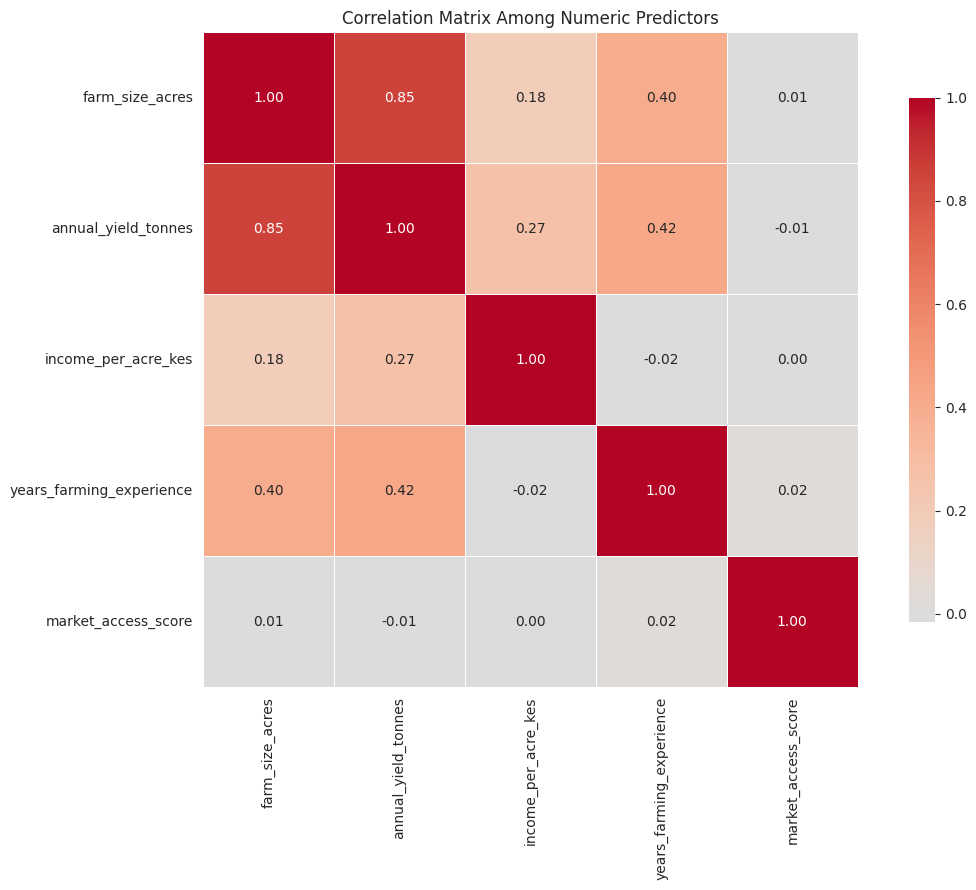

In [ ]:
plt.figure(figsize=(12, 9))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix Among Numeric Predictors")
plt.tight_layout()
plt.show()

From the heatmap, annual_yield_tonnes and farm_size_acres show a very high correlation of 0.85. This suggests they have related information to the distance calculation. Including both features in the clustering algorithm may give this shared information greater influence on the resulting clusters."

##4. Preprocessing pipeline (scaling and missing data)

# 4.1 Investigating whether there is a relationship between the missing data and other features

In [ ]:
categorical_missing = pd.crosstab(
    df["crop_type"],
    df["market_access_score"].isna().map({
        False: "Present",
        True: "Missing"
    })
)

print("Counts within each crop type:")
print(categorical_missing)

print("\nPercentages within each crop type:")
categorical_missing_pct = pd.crosstab(
    df["crop_type"],
    df["market_access_score"].isna().map({
        False: "Present",
        True: "Missing"
    }),
    normalize="index"
) * 100

print(categorical_missing_pct.round(2))

Counts within each crop type:
market_access_score  Missing  Present
crop_type                            
Coffee                     6      113
Dairy                      5       96
Horticulture               7      128
Maize                      8      208
Tea                        4      105

Percentages within each crop type:
market_access_score  Missing  Present
crop_type                            
Coffee                  5.04    94.96
Dairy                   4.95    95.05
Horticulture            5.19    94.81
Maize                   3.70    96.30
Tea                     3.67    96.33


In [ ]:
numeric_missing = df["market_access_score"].isna().map({
    False: "Present",
    True: "Missing"
})

numeric_cols = [
    "farm_size_acres",
    "annual_yield_tonnes",
    "income_per_acre_kes",
    "years_farming_experience"
]

print("Mean values by market_access_score status:")

numeric_means = df.groupby(numeric_missing)[numeric_cols].mean().T
numeric_means.columns.name = None
numeric_means.index.name = None

print(numeric_means.round(2))

print("\nPercentages by market_access_score status:")

numeric_counts = df.groupby(numeric_missing)[numeric_cols].count().T

numeric_percentages = (
    numeric_counts.div(numeric_counts.sum(axis=1), axis=0)
    * 100
)

numeric_percentages.columns.name = None
numeric_percentages.index.name = None

print(numeric_percentages.round(2))

Mean values by market_access_score status:
                           Missing   Present
farm_size_acres              14.86      9.95
annual_yield_tonnes          36.75     30.43
income_per_acre_kes       52314.33  51895.89
years_farming_experience      9.45     10.29

Percentages by market_access_score status:
                          Missing  Present
farm_size_acres              4.41    95.59
annual_yield_tonnes          4.41    95.59
income_per_acre_kes          4.41    95.59
years_farming_experience     4.41    95.59


There is no direct relationship between the other features and market_access_score.It is equally missing across all other features sugesting that it is missing at random.

# 4.2 Handling the missing data

In [ ]:
# Impute missing market_access_score values using its median
market_access_median = df["market_access_score"].median()

df["market_access_score"] = df["market_access_score"].fillna(
    market_access_median
)

print(f"Median market_access_score used for imputation: {market_access_median:.2f}")
print("\nMissing values after imputation:")
print(df["market_access_score"].isna().sum())

Median market_access_score used for imputation: 53.32

Missing values after imputation:
0


I used median imputation to impute the missing data. The median is 53,32 and after imputation there was no missing data.

# 4.3 Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols_scaled = scaler.fit_transform(df[numeric_cols])

print("Before scaling:")
display(df[numeric_cols].describe().loc[["mean", "std"]].round(2))

print("\nAfter scaling:")
display(pd.DataFrame(numeric_cols_scaled,columns=numeric_cols).describe().loc[["mean", "std"]].round(2))

Before scaling:


,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience
mean,10.16,30.71,51914.35,10.25
std,14.58,55.53,40581.50,6.04



After scaling:


,farm_size_acres,annual_yield_tonnes,income_per_acre_kes,years_farming_experience
mean,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0


Scaling was done to give all the features an equal chance with the algorithm. Had it not been done, income_per_acre_kes income would have a greater impact on the distance calculation simply because  it has a larger numeric range, regardless of its actual importance. After scaling, the mean is 1 and the standard deviation 0.

##5. Determining the optimal number of clusters (k)

##6. Cluster diagnostics

##7. Justification of the final chosen k

##8. Robustness and sensitivity check

##9. Cluster profiling and explainability

##10. Model persistence

##11. Conclusion